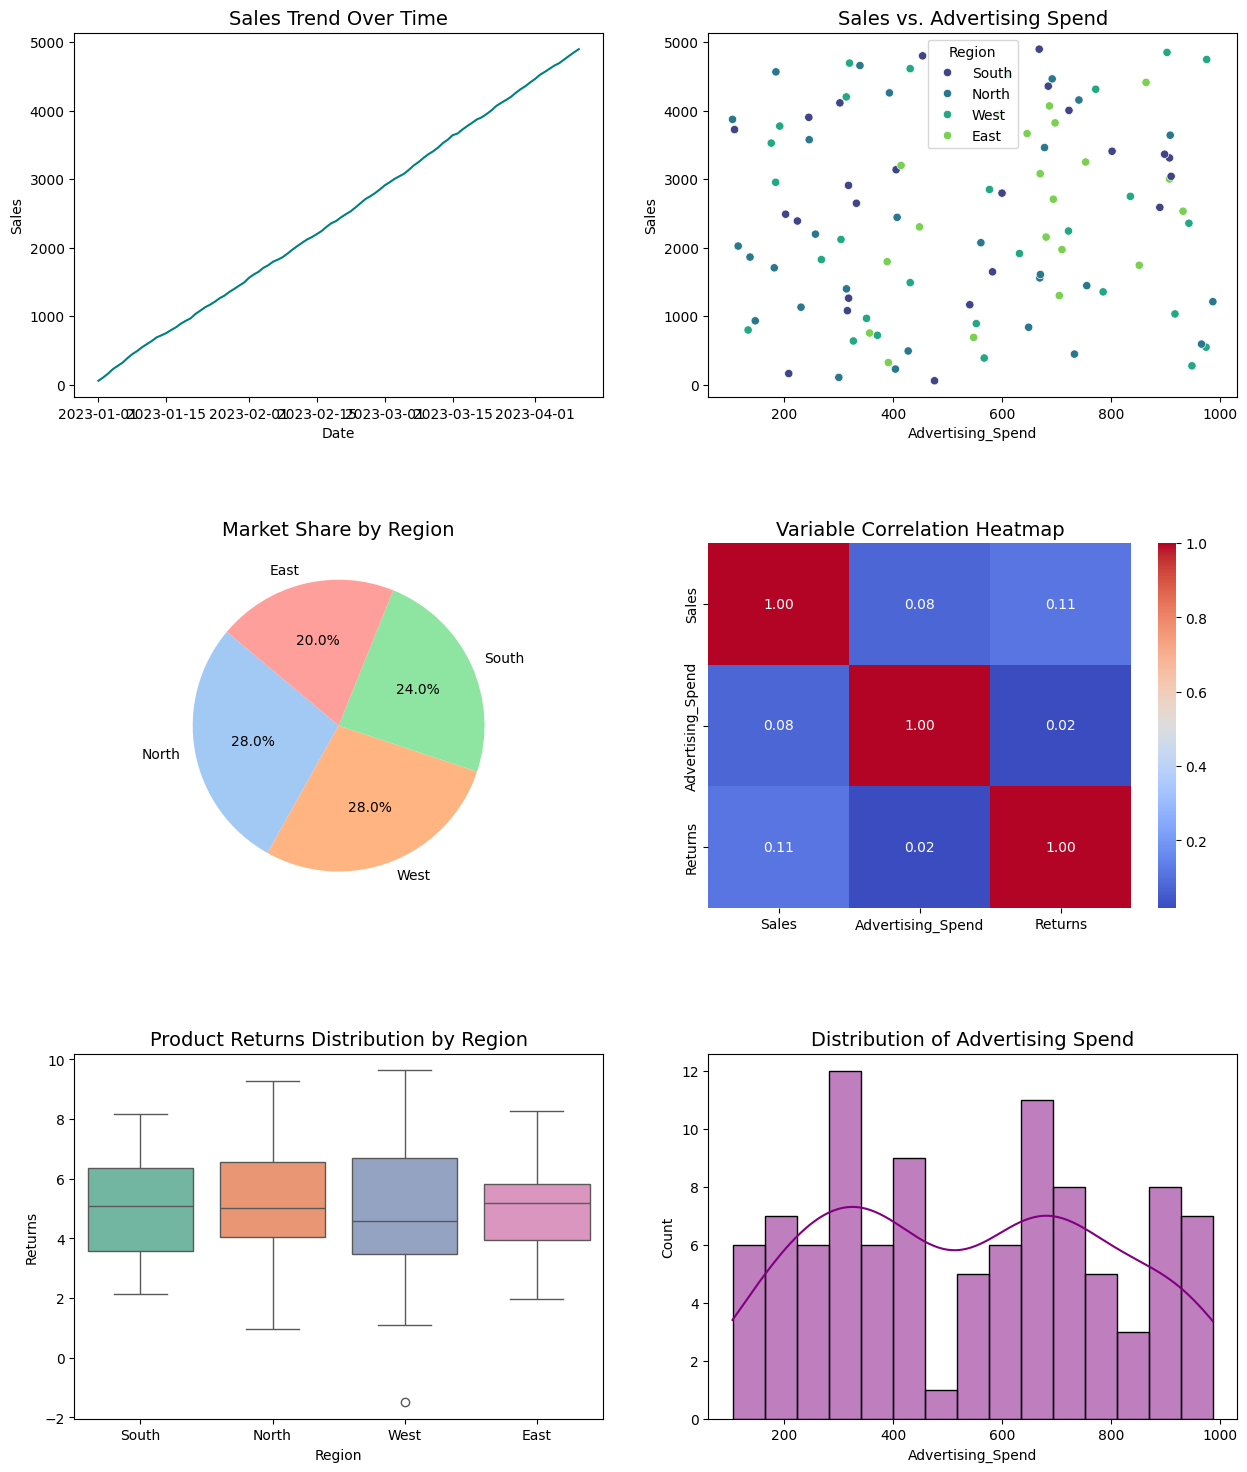

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(42)
data_size = 100
df = pd.DataFrame({
    'Date': pd.date_range(start='2023-01-01', periods=data_size),
    'Sales': np.cumsum(np.random.randn(data_size) * 10 + 50),
    'Advertising_Spend': np.random.uniform(100, 1000, data_size),
    'Region': np.random.choice(['North', 'South', 'East', 'West'], data_size),
    'Returns': np.random.normal(5, 2, data_size)
})
plt.style.use('seaborn-v0_8-muted')
fig, axes = plt.subplots(3, 2, figsize=(15, 18))
plt.subplots_adjust(hspace=0.4)
sns.lineplot(ax=axes[0, 0], x='Date', y='Sales', data=df, color='teal')
axes[0, 0].set_title('Sales Trend Over Time', fontsize=14)
sns.scatterplot(ax=axes[0, 1], x='Advertising_Spend', y='Sales', hue='Region', data=df, palette='viridis')
axes[0, 1].set_title('Sales vs. Advertising Spend', fontsize=14)
region_counts = df['Region'].value_counts()
axes[1, 0].pie(region_counts, labels=region_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
axes[1, 0].set_title('Market Share by Region', fontsize=14)
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(ax=axes[1, 1], data=corr, annot=True, cmap='coolwarm', fmt=".2f")
axes[1, 1].set_title('Variable Correlation Heatmap', fontsize=14)
sns.boxplot(ax=axes[2, 0], x='Region', y='Returns', data=df, hue='Region', palette='Set2', legend=False)
axes[2, 0].set_title('Product Returns Distribution by Region', fontsize=14)
sns.histplot(ax=axes[2, 1], data=df, x='Advertising_Spend', kde=True, color='purple', bins=15)
axes[2, 1].set_title('Distribution of Advertising Spend', fontsize=14)
plt.show()